**Yusuf Fakhri Aldrian - 1906351096**

**Tugas Pemrograman 3 - Penambangan Data**

Javanese GPT-2 IMDB

Kolaborator: Heidi Renata Halim

**Disarankan dan boleh coba dijalankan ulang... karena ada variabel sama dan suka diulang jalan ditengah dibawah ada yg variable nya gaada pas jalan.... kalau ngulang jalanin lumayan lama**

1.	https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html 
2.	https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html 
3.	https://en.wikipedia.org/wiki/Receiver_operating_characteristic
4.	https://betterprogramming.pub/how-to-divide-data-into-train-and-test-assuring-representativeness-c4c12c215d79
5.	https://www.kaggle.com/getting-started/68063
6.	https://colab.research.google.com/drive/1U-Oy9csmOqYUvxYhDuJr42IHT-Ex21sA tutorial_senti_traditional.ipynb - Colaboratory (google.com), Colab Pak Alfan
7.	https://colab.research.google.com/drive/12Jt5Tvzz2_tyMZNwVlfdjSZLQJT21eTR, tutorial_senti_embedding_simple.ipynb - Colaboratory (google.com), Colab Pak Alfan
8.	https://www.geeksforgeeks.org/random-forest-classifier-using-scikit-learn/
9.	https://towardsdatascience.com/interpreting-roc-curve-and-roc-auc-for-classification-evaluation-28ec3983f077
10.	https://aclanthology.org/2020.pam-1.15.pdf 
11.	https://huggingface.co/indolem/indobertweet-base-uncased


# Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import re
import string
import random


In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
!pip install -q gwpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 16.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


# Read Data (CSV to variables)

In [4]:
!gdown --id "13P-euBHMfmgvKW3a4L1DwNe9IvahjQE2"

/usr/local/lib/python3.10/dist-packages/gdown/cli.py:121: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=13P-euBHMfmgvKW3a4L1DwNe9IvahjQE2
To: /content/test.csv
100% 12.5M/12.5M [00:00<00:00, 59.3MB/s]


In [5]:
!gdown --id "173f8bpjVlQiKZqrilPSIkrkSLSsaqbT6"

/usr/local/lib/python3.10/dist-packages/gdown/cli.py:121: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=173f8bpjVlQiKZqrilPSIkrkSLSsaqbT6
To: /content/train.csv
100% 12.6M/12.6M [00:00<00:00, 34.8MB/s]


In [6]:
!gdown --id "1hPkzMWclng5YYyNi_c4vC9hsk_or5KN2"

/usr/local/lib/python3.10/dist-packages/gdown/cli.py:121: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1hPkzMWclng5YYyNi_c4vC9hsk_or5KN2
To: /content/unsupervised.csv
100% 25.3M/25.3M [00:00<00:00, 47.3MB/s]


In [7]:
# train.csv

train_data_df = pd.read_csv('train.csv')

train_data_df.head(5)

,id,label,text
0,0,1,"Wektu teka, wong enom sing dikirim ing dhaérah..."
1,1,1,Thomas Beckett & Richard Miller - loro manungs...
2,2,0,"Oke, aku wis ndelok film iki ping pindho saiki..."
3,3,0,Aku seneng karo aktor/aktress sing mlebu ing p...
4,4,1,Ana cerita (mbokmenawa apokrifa) bab wichingan...


Cleaning

In [8]:
# Lower
train_data_df['text_cleaned'] = train_data_df['text'].apply(lambda x: x.lower())

# Remove Whitespace
train_data_df['text_cleaned']=train_data_df['text_cleaned'].apply(lambda x: re.sub(' +',' ',x))

# Remove Digit
train_data_df['text_cleaned']=train_data_df['text_cleaned'].apply(lambda x: re.sub('\w*\d\w*',' ', x))

# Remove Line Break
train_data_df['text_cleaned']=train_data_df['text_cleaned'].apply(lambda x: re.sub('<br\s*/*>',' ', x))
train_data_df['text_cleaned']=train_data_df['text_cleaned'].apply(lambda x: re.sub('/(^|[^\n\r])[\r\n](?![\n\r])/',' ', x))
train_data_df['text_cleaned']=train_data_df['text_cleaned'].apply(lambda x: re.sub('/(<|&lt;)br\s*\/*(>|&gt;)/',' ', x))

# Remove Punctuation
train_data_df['text_cleaned']=train_data_df['text_cleaned'].apply(lambda x: re.sub('[%s]' % re.escape(string.punctuation), ' ', x))

# Remove Whitespace
train_data_df['text_cleaned']=train_data_df['text_cleaned'].apply(lambda x: re.sub(' +',' ',x))




In [9]:
train_data_df['text']

0        Wektu teka, wong enom sing dikirim ing dhaérah...
1        Thomas Beckett & Richard Miller - loro manungs...
2        Oke, aku wis ndelok film iki ping pindho saiki...
3        Aku seneng karo aktor/aktress sing mlebu ing p...
4        Ana cerita (mbokmenawa apokrifa) bab wichingan...
                               ...                        
24995    Kuwi ora isa metu ora mèlu netralite.<br /><br...
24996    Film iki bodho banget wektu mulai kelakon. Aku...
24997    Documentary dimulai taun 1986 ing NYC ing dhaé...
24998    Aku ing Belgian lan ditumbuhké ing sepuluh. Si...
24999    Lots lan akèh informasi sing digester, lan jik...
Name: text, Length: 25000, dtype: object

In [10]:
train_data_df['text_cleaned']

0        wektu teka wong enom sing dikirim ing dhaérah ...
1        thomas beckett richard miller loro manungsa si...
2        oke aku wis ndelok film iki ping pindho saiki ...
3        aku seneng karo aktor aktress sing mlebu ing p...
4        ana cerita mbokmenawa apokrifa bab wichingan a...
                               ...                        
24995    kuwi ora isa metu ora mèlu netralite yeh iki c...
24996    film iki bodho banget wektu mulai kelakon aku ...
24997    documentary dimulai taun ing nyc ing dhaérah b...
24998    aku ing belgian lan ditumbuhké ing sepuluh sin...
24999    lots lan akèh informasi sing digester lan jika...
Name: text_cleaned, Length: 25000, dtype: object

# TF IDF dan Random Forest Classifier

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer

docs, labels = [], []
for (_, row) in train_data_df.iterrows():
  docs.append(row['text_cleaned'])
  labels.append(row['label'])

labels = np.array(labels)

# tf-idf vectorizer
tfidf_vectorize = TfidfVectorizer(max_df = 0.7, min_df = 0.001)
tfidf_data = tfidf_vectorize.fit_transform(docs)

print(tfidf_data.shape)
print(labels.shape)


(25000, 4001)
(25000,)


In [ ]:
from sklearn.model_selection import train_test_split
X = tfidf_data # fitur-fitur
y = labels     # label

# training = 70%
# testing = 30%
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = 0.30, 
                                                    random_state = 0
                                                   )

## Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# model ensemble

model = RandomForestClassifier()
classifier = model.fit(tfidf_data, labels) 

In [ ]:
# jika ada reviews baru
unseen_reviews = ['Aku ora mempeng nulis wicaksana iki, ning malah maca wicaksana sing URL Evangelist, aku rumangsa dikongsi kanggo nulis film. Film ing tembung sing paling luhur. Film kuwi ora pantes diundang sing nulis penulis. Saya pikir, penulis kuwi wis nggolÃ¨k film sing sampurna. Maksudku, aku uga dijawab pendidikan agama sing terlalu nerangkÃ©. Ning, aku kudu njawab agama sing ngganggu agama sing dimaksud utawa dijawab.',
                  'jelek',
                  'apik.']

# kita transformasi dulu/kita ekstrak fitur TF-IDF dari unseen reviews tersebut
tfidf_unseen_data = tfidf_vectorize.transform(unseen_reviews)

predictions = classifier.predict(tfidf_unseen_data)

for i, unseen_review in enumerate(unseen_reviews):
  print('{} \n(predicted label: {})\n'.format(
                                          unseen_review, 
                                          ('positive' if predictions[i] > 0.8 else 'negative')
                                        ))

Aku ora mempeng nulis wicaksana iki, ning malah maca wicaksana sing URL Evangelist, aku rumangsa dikongsi kanggo nulis film. Film ing tembung sing paling luhur. Film kuwi ora pantes diundang sing nulis penulis. Saya pikir, penulis kuwi wis nggolÃ¨k film sing sampurna. Maksudku, aku uga dijawab pendidikan agama sing terlalu nerangkÃ©. Ning, aku kudu njawab agama sing ngganggu agama sing dimaksud utawa dijawab. 
(predicted label: positive)

jelek 
(predicted label: negative)

apik. 
(predicted label: positive)



### Evaluasi Random Forest

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, precision_recall_curve
from sklearn.metrics import confusion_matrix, roc_curve, auc

In [ ]:
# kita evaluasi dengan model RandomForestClassifier
model = RandomForestClassifier()
clf = model.fit(X_train, y_train) # proses fitting di data training
predictions = clf.predict(X_test)
cm = confusion_matrix(y_test, predictions, labels=clf.classes_)




In [ ]:
X

<25000x4001 sparse matrix of type '<class 'numpy.float64'>'
	with 1003542 stored elements in Compressed Sparse Row format>

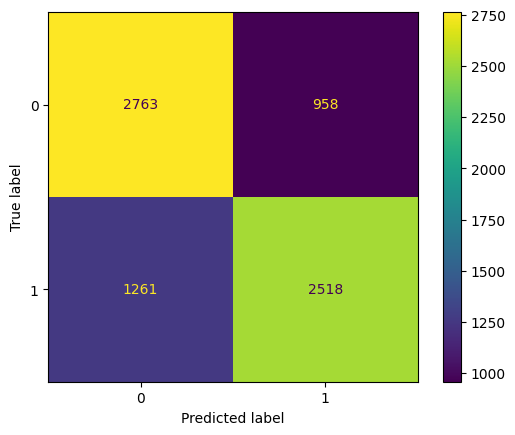

In [ ]:
# Confusion Matrix
cmd = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=clf.classes_)
cmd.plot()
plt.show()

(array([0.50386667, 0.72439586, 1.        ]), array([1.        , 0.66631384, 0.        ]), array([0, 1]))


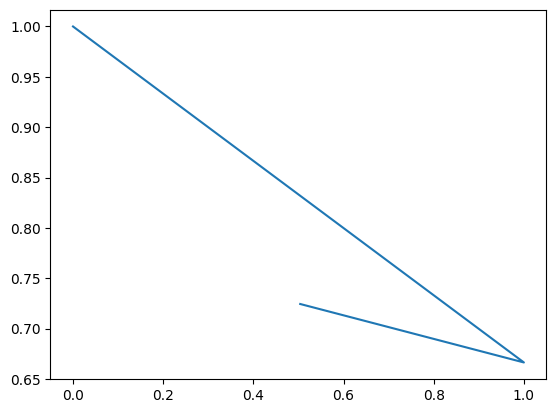

In [ ]:
# Precision-Recall Curve
prc = precision_recall_curve(y_test, predictions) # positive = 1 (sentiment positif)
x_val = [x[0] for x in prc]
y_val = [x[1] for x in prc]

print(prc)


plt.plot(x_val,y_val)
plt.show()

[]

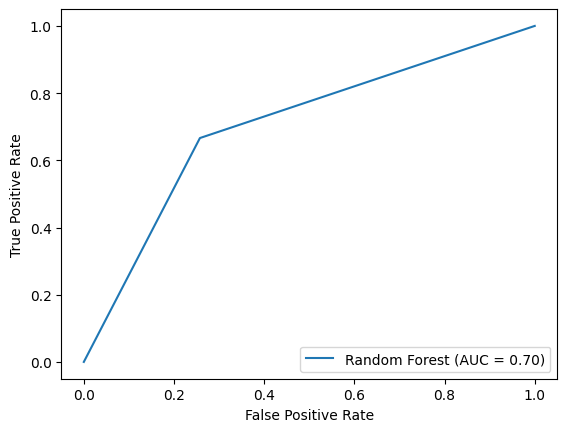

In [ ]:
# ROC curve cocok kalau datanya balance, yang lebih cocok untuk data yang tidak balance


fpr, tpr, thresholds = roc_curve(y_test, predictions)
roc_auc = auc(fpr, tpr)
rocd = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                   estimator_name='Random Forest') # positive = 1 (sentiment positif)

rocd.plot()
plt.plot()

## Model SVC

In [ ]:
from sklearn.svm import SVC
svc = SVC()
svc.fit(X_train, y_train)
y_pred = svc.predict(X_test)

## Model SGDC

In [ ]:
from sklearn.linear_model import SGDClassifier

sgdc = SGDClassifier(max_iter=10000, tol=0.01, random_state = 5)

 
sgdc.fit(X_train, y_train)

SGDClassifier(max_iter=10000, random_state=5, tol=0.01)

# Evaluasi dan Test 

---



## Evaluasi dan Test IMDB

### TF-IDF dengan Random Forest Classifier dan SVC

In [ ]:
!gdown --id "1Hlgwb97IXAZYA8fOY59xwPdL_IQR2gV5"

!gdown --id "1HQc7DFEc-Je-HSMdzaxBZ8dYn_M59J0O"

/usr/local/lib/python3.10/dist-packages/gdown/cli.py:121: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1Hlgwb97IXAZYA8fOY59xwPdL_IQR2gV5
To: /content/javanese_imdb_test.csv
100% 12.4M/12.4M [00:00<00:00, 112MB/s] 
/usr/local/lib/python3.10/dist-packages/gdown/cli.py:121: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1HQc7DFEc-Je-HSMdzaxBZ8dYn_M59J0O
To: /content/javanese_imdb_train.csv
100% 12.4M/12.4M [00:00<00:00, 115MB/s]


In [ ]:
df_imdb_1 = pd.read_csv("javanese_imdb_train.csv")
df_imdb_2 = pd.read_csv("javanese_imdb_test.csv")
df_imdb = df_imdb_2 #.append(df_imdb_1)
df_imdb_preserve = df_imdb.copy()
df_imdb

,label,text
0,1,Aku mlebu lan ndelok film iki sewengi sakwisé ...
1,1,Aktor pelayan Bill Paxton mèlu debut sing janj...
2,1,"Kaya golf rekreasi sing kenal sejarah sport, a..."
3,1,"Aku ndelok film iki nganggo nggawe, lan kuwi n..."
4,1,Bill Paxton nggawa crita sing sejati bab golf ...
...,...,...
24995,0,Kadhang kala aku nganti anak - anakku ndelok k...
24996,0,Wektu kita isih nduwé tél TV sing mlebu ngangg...
24997,0,Genre sing dasar digawe nganggo striller inter...
24998,0,Patang barang sing nggumun aku nggatèkké film ...


In [ ]:
# Lower
df_imdb['text_cleaned'] = df_imdb['text'].apply(lambda x: x.lower())

# Remove Whitespace
df_imdb['text_cleaned']=df_imdb['text_cleaned'].apply(lambda x: re.sub(' +',' ',x))

# Remove Digit
df_imdb['text_cleaned']=df_imdb['text_cleaned'].apply(lambda x: re.sub('\w*\d\w*',' ', x))

# Remove Line Break
df_imdb['text_cleaned']=df_imdb['text_cleaned'].apply(lambda x: re.sub('<br\s*/*>',' ', x))
df_imdb['text_cleaned']=df_imdb['text_cleaned'].apply(lambda x: re.sub('/(^|[^\n\r])[\r\n](?![\n\r])/',' ', x))
df_imdb['text_cleaned']=df_imdb['text_cleaned'].apply(lambda x: re.sub('/(<|&lt;)br\s*\/*(>|&gt;)/',' ', x))

# Remove Punctuation
df_imdb['text_cleaned']=df_imdb['text_cleaned'].apply(lambda x: re.sub('[%s]' % re.escape(string.punctuation), ' ', x))

# Remove Whitespace
df_imdb['text_cleaned']=df_imdb['text_cleaned'].apply(lambda x: re.sub(' +',' ',x))

In [ ]:
docs = []
untukprediksi_imdb = df_imdb["text_cleaned"]


for (_, row) in df_imdb.iterrows():
  docs.append(row['text_cleaned'])

#untukprediksi_tfidf_vectorize = TfidfVectorizer(max_df = 0.7, min_df = 0.001)
#untukprediksi_tfidf_data = tfidf_vectorize.fit_transform(docs)

untukprediksi_imdb_tfidf_unseen_data = tfidf_vectorize.transform(docs)

In [ ]:
classifypredict_imdb_untukprediksi = classifier.predict(untukprediksi_imdb_tfidf_unseen_data)

In [ ]:
classifypredict_imdb_untukprediksi

array([0, 1, 1, ..., 1, 1, 1])

In [ ]:
#accuracy_score(y_true, y_pred)
from sklearn.metrics import accuracy_score

truescore = df_imdb['label']

print(accuracy_score(truescore,classifypredict_imdb_untukprediksi))

0.695


In [ ]:
imdb_svc_predict = svc.predict(untukprediksi_imdb_tfidf_unseen_data)

In [ ]:
truescore = df_imdb['label']

print(accuracy_score(truescore,imdb_svc_predict))

0.72404


## Evaluasi dan Test Final

### Preparasi

In [27]:
df_test = pd.read_csv("test.csv")
df_test_preserve = df_test.copy()
df_test

,id,text
0,0,Aku ndelok iki ing omahé bojoku sewengi wengi ...
1,1,"""Bernard McEveety"" kuwi mulai nganggo bapak Ch..."
2,2,Batman Return's sing nggumunku. Film sing apik...
3,3,Apa sing isa dikatakan panjenengan bab film si...
4,4,Iki Kanggo Kaisar Anyar. Ana sing kudu ngomong...
...,...,...
24995,24995,"Film iki sedhih. Menurut para pengguna IMDb, (..."
24996,24996,Gatèkna katrangan iki: Ana siswa bosen sing bo...
24997,24997,Apa sebabé ora isa didelok film sing jeneng 0?...
24998,24998,"Mangkono wong-orang, aku tresna gawéan Ray Bol..."


In [28]:
# Lower
df_test['text_cleaned'] = df_test['text'].apply(lambda x: x.lower())

# Remove Whitespace
df_test['text_cleaned']=df_test['text_cleaned'].apply(lambda x: re.sub(' +',' ',x))

# Remove Digit
df_test['text_cleaned']=df_test['text_cleaned'].apply(lambda x: re.sub('\w*\d\w*',' ', x))

# Remove Line Break
df_test['text_cleaned']=df_test['text_cleaned'].apply(lambda x: re.sub('<br\s*/*>',' ', x))
df_test['text_cleaned']=df_test['text_cleaned'].apply(lambda x: re.sub('/(^|[^\n\r])[\r\n](?![\n\r])/',' ', x))
df_test['text_cleaned']=df_test['text_cleaned'].apply(lambda x: re.sub('/(<|&lt;)br\s*\/*(>|&gt;)/',' ', x))

# Remove Punctuation
df_test['text_cleaned']=df_test['text_cleaned'].apply(lambda x: re.sub('[%s]' % re.escape(string.punctuation), ' ', x))

# Remove Whitespace
df_test['text_cleaned']=df_test['text_cleaned'].apply(lambda x: re.sub(' +',' ',x))

In [29]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier

In [30]:
#regressor = RandomForestRegressor(n_estimators = 50, random_state = 42)
#regressor.fit(X_train, y_train)

In [31]:
#classifier = RandomForestClassifier(n_estimators = 50, random_state = 42)
#classifier.fit(X_train, y_train)

In [32]:
#y_pred = classifier.predict(X_test)



In [33]:
#print(y_pred)

#errors = abs(y_pred - y_test)
#print('Mean Absolute Error:', round(np.mean(errors), 2), 'degrees.')

In [34]:
df_test

,id,text,text_cleaned
0,0,Aku ndelok iki ing omahé bojoku sewengi wengi ...,aku ndelok iki ing omahé bojoku sewengi wengi ...
1,1,"""Bernard McEveety"" kuwi mulai nganggo bapak Ch...",bernard mceveety kuwi mulai nganggo bapak cha...
2,2,Batman Return's sing nggumunku. Film sing apik...,batman return s sing nggumunku film sing apik ...
3,3,Apa sing isa dikatakan panjenengan bab film si...,apa sing isa dikatakan panjenengan bab film si...
4,4,Iki Kanggo Kaisar Anyar. Ana sing kudu ngomong...,iki kanggo kaisar anyar ana sing kudu ngomong ...
...,...,...,...
24995,24995,"Film iki sedhih. Menurut para pengguna IMDb, (...",film iki sedhih menurut para pengguna imdb spo...
24996,24996,Gatèkna katrangan iki: Ana siswa bosen sing bo...,gatèkna katrangan iki ana siswa bosen sing bos...
24997,24997,Apa sebabé ora isa didelok film sing jeneng 0?...,apa sebabé ora isa didelok film sing jeneng ut...
24998,24998,"Mangkono wong-orang, aku tresna gawéan Ray Bol...",mangkono wong orang aku tresna gawéan ray bolg...


In [35]:
docs = []
untukprediksi = df_test["text_cleaned"]


for (_, row) in df_test.iterrows():
  docs.append(row['text_cleaned'])

#untukprediksi_tfidf_vectorize = TfidfVectorizer(max_df = 0.7, min_df = 0.001)
#untukprediksi_tfidf_data = tfidf_vectorize.fit_transform(docs)

untukprediksi_tfidf_unseen_data = tfidf_vectorize.transform(docs)

NameError: ignored

In [ ]:
print(len(docs))

### Random Forest

In [ ]:
classifypredict_untukprediksi = classifier.predict(untukprediksi_tfidf_unseen_data)

In [ ]:
classifypredict_untukprediksi

array([0, 0, 1, ..., 0, 1, 0])

In [ ]:
df_pred = df_test_preserve.copy()

In [ ]:
print(df_test.shape)
print(df_pred.shape)
print(classifypredict_untukprediksi.shape)

(25000, 3)
(25000, 2)
(25000,)


In [ ]:
df_pred.insert(1, 'label', classifypredict_untukprediksi)

In [ ]:
df_pred

,id,label,text
0,0,0,Aku ndelok iki ing omahé bojoku sewengi wengi ...
1,1,0,"""Bernard McEveety"" kuwi mulai nganggo bapak Ch..."
2,2,1,Batman Return's sing nggumunku. Film sing apik...
3,3,1,Apa sing isa dikatakan panjenengan bab film si...
4,4,0,Iki Kanggo Kaisar Anyar. Ana sing kudu ngomong...
...,...,...,...
24995,24995,0,"Film iki sedhih. Menurut para pengguna IMDb, (..."
24996,24996,0,Gatèkna katrangan iki: Ana siswa bosen sing bo...
24997,24997,0,Apa sebabé ora isa didelok film sing jeneng 0?...
24998,24998,1,"Mangkono wong-orang, aku tresna gawéan Ray Bol..."


In [ ]:
df_pred_fin = df_pred.copy()
df_pred_fin = df_pred_fin.drop(columns = ["text"])

In [ ]:
df_pred_fin

,id,label
0,0,0
1,1,0
2,2,1
3,3,1
4,4,0
...,...,...
24995,24995,0
24996,24996,0
24997,24997,0
24998,24998,1


In [ ]:
name = 'Yusuf Fakhri Aldrian'
npm = '1906351096'

df_pred_fin.to_csv(
    '{}_{}_{}.csv'.format(npm, name, "tfidf_randomforest"),
    index=False
)

### SVM/SVC

In [ ]:
final_svc_predict = svc.predict(untukprediksi_tfidf_unseen_data)

In [ ]:
df_svm = df_test_preserve.copy()
df_svm = df_svm.drop(columns = ["text"])
df_svm.insert(1, 'label', final_svc_predict)

In [ ]:
name = 'Yusuf Fakhri Aldrian'
npm = '1906351096'

df_svm.to_csv(
    '{}_{}_{}.csv'.format(npm, name, "tfidf_svc"),
    index=False
)

### SGDC

In [ ]:
ypred_sgdc = sgdc.predict(untukprediksi_tfidf_unseen_data)

In [ ]:
print(ypred_sgdc)
print(ypred_sgdc.shape)

[1 0 1 ... 0 1 0]
(25000,)


In [ ]:
df_sgdc = df_test_preserve.copy()
df_sgdc = df_sgdc.drop(columns = ["text"])
df_sgdc.insert(1, 'label', ypred_sgdc)

In [ ]:
name = 'Yusuf Fakhri Aldrian'
npm = '1906351096'

df_sgdc.to_csv(
    '{}_{}_{}.csv'.format(npm, name, "tfidf_sgdc"),
    index=False
)

### Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB
gnb = MultinomialNB()
y_pred_bayes = gnb.fit(X_train, y_train).predict(untukprediksi_tfidf_unseen_data)

In [ ]:
df_bayes = df_test_preserve.copy()
df_bayes = df_bayes.drop(columns = ["text"])
df_bayes.insert(1, 'label', y_pred_bayes)

In [ ]:
name = 'Yusuf Fakhri Aldrian'
npm = '1906351096'

df_bayes.to_csv(
    '{}_{}_{}.csv'.format(npm, name, "tfidf_bayes"),
    index=False
)

# BERT

## Import

In [11]:
!pip install transformers

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 15.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 19.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 42.2 MB/s eta 0:00:00


In [12]:
import tensorflow as tf

import torch
import torch.nn.functional as F
import torch.nn as nn

from transformers import AutoTokenizer, AutoModel, get_constant_schedule_with_warmup
from transformers import TrainingArguments, Trainer, AutoConfig
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler

## Preparation

In [13]:
# misal, diberikan kumpulan dokumen, ada yang berupa sebuah kalimat, dan yang
# yang berupa pasangan kalimat
# [0, 1] -> negatif
# [1, 0] -> positif

train_data_df_bert = train_data_df.copy()

In [14]:
# Lower
train_data_df_bert['text_cleaned'] = train_data_df_bert['text'] #.apply(lambda x: x.lower())

# Remove Digit
#train_data_df_bert['text_cleaned']=train_data_df_bert['text_cleaned'].apply(lambda x: re.sub('\w*\d\w*',' ', x))

# Remove Line Break
train_data_df_bert['text_cleaned']=train_data_df_bert['text_cleaned'].apply(lambda x: re.sub('<br\s*/*>',' ', x))
train_data_df_bert['text_cleaned']=train_data_df_bert['text_cleaned'].apply(lambda x: re.sub('/(^|[^\n\r])[\r\n](?![\n\r])/',' ', x))
train_data_df_bert['text_cleaned']=train_data_df_bert['text_cleaned'].apply(lambda x: re.sub('/(<|&lt;)br\s*\/*(>|&gt;)/',' ', x))

# Remove Punctuation
#train_data_df_bert['text_cleaned']=train_data_df_bert['text_cleaned'].apply(lambda x: re.sub('[%s]' % re.escape(string.punctuation), ' ', x))

# Remove Whitespace
train_data_df_bert['text_cleaned']=train_data_df_bert['text_cleaned'].apply(lambda x: re.sub(' +',' ',x))

In [15]:
train_data_df_bert.dropna()

,id,label,text,text_cleaned
0,0,1,"Wektu teka, wong enom sing dikirim ing dhaérah...","Wektu teka, wong enom sing dikirim ing dhaérah..."
1,1,1,Thomas Beckett & Richard Miller - loro manungs...,Thomas Beckett & Richard Miller - loro manungs...
2,2,0,"Oke, aku wis ndelok film iki ping pindho saiki...","Oke, aku wis ndelok film iki ping pindho saiki..."
3,3,0,Aku seneng karo aktor/aktress sing mlebu ing p...,Aku seneng karo aktor/aktress sing mlebu ing p...
4,4,1,Ana cerita (mbokmenawa apokrifa) bab wichingan...,Ana cerita (mbokmenawa apokrifa) bab wichingan...
...,...,...,...,...
24995,24995,1,Kuwi ora isa metu ora mèlu netralite.<br /><br...,Kuwi ora isa metu ora mèlu netralite. Yeh iki ...
24996,24996,0,Film iki bodho banget wektu mulai kelakon. Aku...,Film iki bodho banget wektu mulai kelakon. Aku...
24997,24997,1,Documentary dimulai taun 1986 ing NYC ing dhaé...,Documentary dimulai taun 1986 ing NYC ing dhaé...
24998,24998,1,Aku ing Belgian lan ditumbuhké ing sepuluh. Si...,Aku ing Belgian lan ditumbuhké ing sepuluh. Si...


In [16]:
train_data_df_bert.drop(['id', 'text'], axis=1)

,label,text_cleaned
0,1,"Wektu teka, wong enom sing dikirim ing dhaérah..."
1,1,Thomas Beckett & Richard Miller - loro manungs...
2,0,"Oke, aku wis ndelok film iki ping pindho saiki..."
3,0,Aku seneng karo aktor/aktress sing mlebu ing p...
4,1,Ana cerita (mbokmenawa apokrifa) bab wichingan...
...,...,...
24995,1,Kuwi ora isa metu ora mèlu netralite. Yeh iki ...
24996,0,Film iki bodho banget wektu mulai kelakon. Aku...
24997,1,Documentary dimulai taun 1986 ing NYC ing dhaé...
24998,1,Aku ing Belgian lan ditumbuhké ing sepuluh. Si...


In [17]:
commennnt = '''traindatalooped = []
for (i, row) in train_data_df_bert.iterrows():
  #docs.append(row['text_cleaned'])
  #labels.append(row['label'])
  perloop = []
  #print(row['text_cleaned'])

  #row['text_cleaned'] = row['text_cleaned'].replace(';', '.')
  #row['text_cleaned'] = row['text_cleaned'].replace(',', '.')
  #row['text_cleaned'] = re.sub('[%s]' % re.escape(string.punctuation), ' ', row['text_cleaned'])

  #train_data_df_bert.at[i,'text_cleaned'] = row['text_cleaned']


  strp = row['text_cleaned'].split(".")
  
  perloop.append(str(row['text_cleaned']))

  if(row['label'] == 1):
    perloop.append(tuple([1,0]))
    #print("[1,0]")
  else:
    perloop.append(tuple([0,1]))
    #print("[0,1]")

  #break
  traindatalooped.append(tuple(perloop))'''

In [18]:
# misal, diberikan kumpulan dokumen, ada yang berupa sebuah kalimat, dan yang
# yang berupa pasangan kalimat
# [0, 1] -> negatif
# [1, 0] -> positif

traindatalooped = []
for (i, row) in train_data_df_bert.iterrows():
  #docs.append(row['text_cleaned'])
  #labels.append(row['label'])
  perloop = []
  #print(row['text_cleaned'])

  row['text_cleaned'] = row['text_cleaned'].replace(';', '.')
  row['text_cleaned'] = row['text_cleaned'].replace(',', '.')
  #row['text_cleaned'] = re.sub('[%s]' % re.escape(string.punctuation), ' ', row['text_cleaned'])

  #train_data_df_bert.at[i,'text_cleaned'] = row['text_cleaned']


  strp = row['text_cleaned'].split(". ")
  
  perloop.append(str(row['text_cleaned']))

  cmnt =   '''
  if len(strp) == 0:
    continue
    print("0")
    perloop.append("Kosong")
  elif len(strp) == 1:
    continue
    ss = row['text_cleaned']
    ss = re.sub('[%s]' % re.escape(string.punctuation), ' ', ss)
    if str(ss) == "" or str(ss) == " ":
      perloop.append("Kosong")
    elif not (type(ss ) == str):
      perloop.append("Kosong")
    elif len(ss)>0:
      perloop.append(str(row['text_cleaned']))
    else:
      perloop.append("")
  elif len(strp) > 1:
    
    #perloop.append(str(row['text_cleaned']))
    tup = []
    
    for ss in strp:
      #ss = re.sub('[%s]' % re.escape(string.punctuation), ' ', ss)
      #print(ss)
      ss = re.sub(' +',' ', ss)
      if (type(ss) == str):
        if ss == "" or ss == " ":
          #print("ss")
          continue
          tup.append(str(""))
        elif len(ss) < 1:
          continue
          tup.append(str(""))
        elif len(ss) > 0:
          tup.append(str(ss))
        else:
          continue
          print("hello")
          tup.append(str(""))
      else:
        continue
        tup.append(str(""))
    tupl = tuple(tup)
    if not tupl:
      print("A: ", ss)
      perloop.append("Kosong")
    elif len(tupl) > 0:
      perloop.append(tupl)
    else:
      print("")
      perloop.append("Kosong")
  else:
    perloop.append("Kosong")
'''


  if(row['label'] == 1):
    perloop.append(tuple([1,0]))
    #print("[1,0]")
  else:
    perloop.append(tuple([0,1]))
    #print("[0,1]")

  #break
  traindatalooped.append((perloop))


train_data = traindatalooped.copy()

In [19]:
komentarrrr = """
for i, j in traindatalooped:
  if isinstance(i, tuple) : #and list(map(type, i)) == [str, int]
    for aa in i:
      if  isinstance(aa, str):
        if len(aa) < 1:
          print(aa)
      else:
        print("kok bisa")
  elif isinstance(i, str):
    continue
    print(i)
  else:
    if " " in i:
      print("here")
    elif not all(i):
      print("gaada")
    elif len(i) > 0:
      pass
    else:
      print("ih")
"""


In [20]:
train_data_df_bert

,id,label,text,text_cleaned
0,0,1,"Wektu teka, wong enom sing dikirim ing dhaérah...","Wektu teka, wong enom sing dikirim ing dhaérah..."
1,1,1,Thomas Beckett & Richard Miller - loro manungs...,Thomas Beckett & Richard Miller - loro manungs...
2,2,0,"Oke, aku wis ndelok film iki ping pindho saiki...","Oke, aku wis ndelok film iki ping pindho saiki..."
3,3,0,Aku seneng karo aktor/aktress sing mlebu ing p...,Aku seneng karo aktor/aktress sing mlebu ing p...
4,4,1,Ana cerita (mbokmenawa apokrifa) bab wichingan...,Ana cerita (mbokmenawa apokrifa) bab wichingan...
...,...,...,...,...
24995,24995,1,Kuwi ora isa metu ora mèlu netralite.<br /><br...,Kuwi ora isa metu ora mèlu netralite. Yeh iki ...
24996,24996,0,Film iki bodho banget wektu mulai kelakon. Aku...,Film iki bodho banget wektu mulai kelakon. Aku...
24997,24997,1,Documentary dimulai taun 1986 ing NYC ing dhaé...,Documentary dimulai taun 1986 ing NYC ing dhaé...
24998,24998,1,Aku ing Belgian lan ditumbuhké ing sepuluh. Si...,Aku ing Belgian lan ditumbuhké ing sepuluh. Si...


In [21]:

pd.DataFrame(traindatalooped).isnull().any()

0    False
1    False
dtype: bool

In [22]:
i=0
for ii in traindatalooped:
  print(ii)
  i+=1
  if i==40:
    break

['Wektu teka. wong enom sing dikirim ing dhaérah sing adoh kanggo numpak tandhané klien sing wis mati. Wektu teka. dhèwèké ngrasa nèk wong wédok sing ditampa kurang timbang wong - wong désa lan klien sing wis mati ora seneng. Kanggo cepet - cepet nggolèk panggonan saka ing kono lan manggon ing omahé. omah sing biyasané lumrah lan cedhak mung merga wewedhungané laut. Wektu ndelok wong wédok sing dinggo ireng. kuwi nyata utawa dipikir. dhèwèké uga digawé kanggo nggolèk jenengé geréja sing tumrap saka kono lan bocah - bocah ing kono. aku mung ngentèni wernané TV lan ora suwé.', (1, 0)]
['Thomas Beckett & Richard Miller - loro manungsa sing péngin urip ing "junggle" kasar lan mudnes. salah siji tembakan - sing dipatèni!!! Kowe kudu matèni. nèk panjenengan ragu - raguna bab apa. AKON SURVIVE!! P.P.- Aku nggolèk sing salah / sing jahat/ Inggris!!!!!', (1, 0)]
["Oke. aku wis ndelok film iki ping pindho saiki. aku nduwèk penyelidikan game ing nete. aku takon beberapa wong ana pendapat. Malah a

In [23]:
#train_data

#train_data = []
#for i in range(20):
  #train_data.append(traindatalooped[i])


## BERT

## Setup BERT

In [24]:
from transformers import AutoTokenizer, TFBertModel

tokenizer = AutoTokenizer.from_pretrained("w11wo/javanese-bert-small-imdb")

# from_pt = True -> karena model asli merupakan PyTorch Model, bukan TF Model
bert_model = TFBertModel.from_pretrained("w11wo/javanese-bert-small-imdb", \
                                         output_attentions=True, \
                                         from_pt = True)

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.predictions.decoder.weight', 'cls.predictions.decoder.bias', 'cls.predictions.bias', 'cls.predictions.transform.LayerNorm.bias', 'bert.embeddings.position_ids', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFBertModel were not initialized from the PyTorch model and are newly initialized: ['bert.pooler.dense.weight', 'bert.p

In [25]:
DEBUG = False
MAX_LENGTH = 30

documents = [doc for (doc, _) in train_data] 
labels    = [label for (_, label) in train_data]
label_x = labels.copy()

# lihat https://huggingface.co/transformers/preprocessing.html
# yang kita lakukan kali ini adalah: kita padding ke panjang input maksimal
# yang ditemukan di data
def tokenize(documents, is_tuple = False):
  if not is_tuple:
    return tokenizer(documents, padding='max_length', max_length=MAX_LENGTH, truncation=True)
  return tokenizer(documents[0], documents[1], padding='max_length', max_length=MAX_LENGTH, truncation=True)

encoded_inputs = tokenize(documents)
encoded_inputs_1 = encoded_inputs.copy()

# ubah ke numpy array
X_train_ids = np.array(encoded_inputs['input_ids'])
X_train_tid = np.array(encoded_inputs['token_type_ids'])
X_train_ams = np.array(encoded_inputs['attention_mask'])
Y_train     = np.array(labels)

if DEBUG:
  print('Informasi dimensi')
  print(X_train_ids.shape)
  print(X_train_tid.shape)
  print(X_train_ams.shape)
  print(Y_train.shape)

  print('Sequeces of token ids:')
  for doc_ids in encoded_inputs['input_ids']:
    print(doc_ids)

  print('Sequeces of type ids:')
  for type_ids in encoded_inputs['token_type_ids']:
    print(type_ids)

  print('Sequeces of attention mask:')
  for attention_mask in encoded_inputs['attention_mask']:
    print(attention_mask)  

  print('Seandainya kita decode balik:')
  for doc_ids in encoded_inputs['input_ids']:
    print(tokenizer.decode(doc_ids))

In [ ]:
encoded_inputs_1

{'input_ids': [[3, 2494, 4280, 18, 1874, 4072, 1723, 8246, 1648, 7188, 1723, 4494, 1761, 10491, 3528, 2111, 1922, 9458, 1723, 1886, 3637, 18, 2494, 4280, 18, 1839, 8970, 5762, 1874, 1], [3, 5942, 28273, 10, 6547, 16181, 17, 2623, 2519, 1723, 5555, 2365, 1648, 6, 8671, 16804, 1005, 6, 5627, 1662, 8116, 4203, 18, 1876, 1914, 22182, 17, 1723, 9553, 1], [3, 2399, 1005, 18, 4880, 1886, 13844, 2315, 1728, 4620, 7420, 2283, 18, 4880, 2926, 1032, 15674, 3640, 3590, 1648, 4097, 1005, 18, 4880, 14670, 11453, 1874, 1782, 20088, 1], [3, 4880, 3363, 1822, 3735, 19, 1810, 15769, 1723, 3144, 1648, 4571, 1728, 1723, 2593, 1677, 1822, 2315, 1723, 2025, 8985, 29946, 5762, 2115, 2479, 1723, 1848, 2798, 18, 1], [3, 1782, 8867, 12, 8857, 21965, 1985, 1737, 18307, 1008, 13, 1913, 9386, 9032, 1639, 3312, 17292, 29571, 2331, 24738, 5911, 4753, 1648, 12564, 17227, 1670, 2817, 13355, 18, 1], [3, 14, 14, 14, 19176, 3546, 5688, 1026, 5512, 1639, 5474, 1965, 2004, 6213, 28538, 17, 1880, 2972, 2133, 1959, 2972, 184

## Modelling

In [ ]:
# Devlin et al. (penulis BERT) mengusulkan learning rate
# 3e-4, 1e-4, 5e-5, dan 3e-5 sebagai starting point, untuk Adam optimizer
LEARNING_RATE = 3e-5
RANDOM_STATE = 42

weight_initializer = tf.keras.initializers.GlorotNormal(seed = RANDOM_STATE) 

input_ids_layer = tf.keras.layers.Input(shape=(MAX_LENGTH,), 
                                        name='input_ids', 
                                        dtype='int32')

input_attention_mask = tf.keras.layers.Input(shape=(MAX_LENGTH,), 
                                             name='input_attention_mask', 
                                             dtype='int32')

input_type_ids = tf.keras.layers.Input(shape=(MAX_LENGTH,), 
                                       name='input_type_ids', 
                                       dtype='int32')

# ambil hidden state terakhir
#last_hidden_state = bert_model([input_ids_layer, input_attention_mask, input_type_ids]).last_hidden_state
last_hidden_state = bert_model([input_ids_layer, input_attention_mask, input_type_ids]).pooler_output

#cls_last_output = last_hidden_state[:, 0, :]

drop_1_out  = tf.keras.layers.Dropout(0.2)(last_hidden_state)
output = tf.keras.layers.Dense(2, 
                              activation = 'softmax',
                              kernel_initializer = weight_initializer,  
                              bias_initializer = 'zeros',
                              name = 'dense_classifier')(drop_1_out)

model = tf.keras.Model([input_ids_layer, input_attention_mask, input_type_ids], output)

model.compile(tf.keras.optimizers.Adam(learning_rate = LEARNING_RATE), 
              loss=tf.keras.losses.CategoricalCrossentropy(),
              metrics=['accuracy'])

print(model.summary())

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_ids (InputLayer)         [(None, 30)]         0           []                               
                                                                                                  
 input_attention_mask (InputLay  [(None, 30)]        0           []                               
 er)                                                                                              
                                                                                                  
 input_type_ids (InputLayer)    [(None, 30)]         0           []                               
                                                                                                  
 tf_bert_model (TFBertModel)    TFBaseModelOutputWi  109482240   ['input_ids[0][0]',          

## Melakukan Fine Tuning BERT

In [ ]:
# buat setiap layer trainable
# termasuk BERT itu sendiri
# kita juga bisa freeze weights di BERT.

# jika ALL = True, maka semuanya trainable
# jika ALL = False, weights pada BERT kita freeze

ALL = True

if not ALL:
  for layer in bert_model.layers:
    layer.trainable = False

print(model.summary())

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_ids (InputLayer)         [(None, 30)]         0           []                               
                                                                                                  
 input_attention_mask (InputLay  [(None, 30)]        0           []                               
 er)                                                                                              
                                                                                                  
 input_type_ids (InputLayer)    [(None, 30)]         0           []                               
                                                                                                  
 tf_bert_model (TFBertModel)    TFBaseModelOutputWi  109482240   ['input_ids[0][0]',          

In [ ]:
# EPOCH dan LEARNING_RATE perlu disesuaikan lagi tergantung strateginya

EPOCHS = 15
BATCH_SIZE = 10

if ALL:
  # EPOCH jangan telalu besar
  # LEARNING_RATE perlu diperkecil --> 5e-5
  # ini diperlukan agar tidak terjadi "Catastrophic Forgetting"
  EPOCHS = 3
  model.optimizer.learning_rate = 5e-5

# hati-hati, cell ini jangan dijalankan lebih dari sekali. mengapa?
# jika ingin mengulang lagi dari awal:
# 1. cell yang menghidupkan object bert_model harus di-restart
# 2. cell yang mendefinisikan model utama harus di-restart

# akselerasi dengan GPU
# jangan lupa diaktifkan terlebih dahulu GPU-nya
# menu -> Runtime -> change runtime type -> pilih GPU
with tf.device('/device:GPU:0'):

  # Train the model
  train_history1 = model.fit(
      x = [X_train_ids, X_train_ams, X_train_tid],
      y = Y_train,
      epochs = EPOCHS,
      batch_size = BATCH_SIZE,
      #validation_data = ([X_valid_ids, X_valid_ams, X_valid_tid], Y_valid),
      verbose=2
  )

Epoch 1/3
2500/2500 - 276s - loss: 0.6561 - accuracy: 0.6129 - 276s/epoch - 111ms/step
Epoch 2/3
2500/2500 - 204s - loss: 0.5559 - accuracy: 0.7158 - 204s/epoch - 82ms/step
Epoch 3/3
2500/2500 - 204s - loss: 0.4415 - accuracy: 0.8004 - 204s/epoch - 81ms/step


## Evaluasi

In [ ]:
# Prediksi label untuk unseen data

# bungkus kode untuk prediksi sebuah dokumen
def predict_document(document, model):
  tokenized_doc = None
  if type(document) == tuple and len(document) == 2:
    tokenized_doc = tokenize(document, is_tuple = True)
  else:
    tokenized_doc = tokenize(document)
  #print(tokenized_doc)
  return model.predict([np.array([tokenized_doc['input_ids']]), \
                        np.array([tokenized_doc['attention_mask']]), \
                        np.array([tokenized_doc['token_type_ids']])])

unseen_input1 = "gagasan yang disampaikan orang itu sangat baik"
unseen_input2 = "Oke, aku wis ndelok film iki ping pindho saiki, aku nduwÃ¨k penyelidikan game ing nete, aku takon beberapa wong ana pendapat. Malah aku nggawa paling maca Sheridan Lafanu Classic 'Carmilla', buku sing didasarkÃ© karo film iki. Aku rumangsa cara sing paling apik kanggo nerangkÃ© film iki kanggo main wektu ndelok kuwi. Kaya film kuwi ora ana apa sing dimaksud, iki arep maca buku sing original Sheridan Lafanu Classic 'Carmilla', buku sing dimaksud ing Syberia, Mr Lafontine nggawa pendhong koyo ditakon <bbr> thok <bbr> thook <bbr>>, sing dimaksud <bbr> thook //bbr> thook>, yaitu gunanÃ© //dok/dok/dokmen <bbr>, sing dijawangi."
unseen_input3 = ("kemarin senang membeli kamera baru", "Namun barangnya sangat buruk")

print(predict_document(unseen_input1, model))
print(predict_document(unseen_input2, model))
print(predict_document(unseen_input3, model))

1/1 [==============================] - 0s 80ms/step
[[0.10923424 0.8907658 ]]
1/1 [==============================] - 0s 122ms/step
[[0.28934193 0.7106581 ]]
1/1 [==============================] - 0s 108ms/step
[[0.01542251 0.9845775 ]]


In [ ]:
df_test = pd.read_csv("test.csv")
df_test_preserve = df_test.copy()
df_test

In [ ]:
# Lower
df_test['text_cleaned'] = df_test['text'].apply(lambda x: x.lower())

# Remove Whitespace
df_test['text_cleaned']=df_test['text_cleaned'].apply(lambda x: re.sub(' +',' ',x))

# Remove Digit
df_test['text_cleaned']=df_test['text_cleaned'].apply(lambda x: re.sub('\w*\d\w*',' ', x))

# Remove Line Break
df_test['text_cleaned']=df_test['text_cleaned'].apply(lambda x: re.sub('<br\s*/*>',' ', x))
df_test['text_cleaned']=df_test['text_cleaned'].apply(lambda x: re.sub('/(^|[^\n\r])[\r\n](?![\n\r])/',' ', x))
df_test['text_cleaned']=df_test['text_cleaned'].apply(lambda x: re.sub('/(<|&lt;)br\s*\/*(>|&gt;)/',' ', x))

# Remove Punctuation
df_test['text_cleaned']=df_test['text_cleaned'].apply(lambda x: re.sub('[%s]' % re.escape(string.punctuation), ' ', x))

# Remove Whitespace
df_test['text_cleaned']=df_test['text_cleaned'].apply(lambda x: re.sub(' +',' ',x))

In [ ]:
print(0.8721926>0.12780741)

In [ ]:
i=0
df_test["label"] = 1
def isclose(a, b, rel_tol=1e-09, abs_tol=0.0):
    return abs(a-b) <= max(rel_tol * max(abs(a), abs(b)), abs_tol)

for (i, row ) in df_test.iterrows():
  predicted = (predict_document(row['text_cleaned'], model))
  #print(type(predicted))
  print(predicted[0][0], predicted[0][1])
  if predicted[0][0] >= predicted[0][1]:
    df_test.at[i,'label'] = 1
    #print("Satu")

  if predicted[0][0] < predicted[0][1]:
    df_test.at[i,'label'] = 0
    row["label"] = 0
    #print("Noll")
  

  #print(row["text"], row["label"])
  #if i==20:
  #  break
  #i+=1
  


In [ ]:
df_results = df_test.copy()
df_results

In [ ]:
df_results = df_results.drop(['text', 'text_cleaned'], axis=1)

In [ ]:
name = 'Yusuf Fakhri Aldrian'
npm = '1906351096'

df_results.to_csv(
    '{}_{}_{}.csv'.format(npm, name, "bert"),
    index=False
)

## Another BERT

In [36]:
x_df_bert = df_test_preserve.copy()
# Lower
x_df_bert['text_cleaned'] = x_df_bert['text'] #.apply(lambda x: x.lower())

# Remove Digit
#x_df_bert['text_cleaned']=x_df_bert['text_cleaned'].apply(lambda x: re.sub('\w*\d\w*',' ', x))

# Remove Line Break
x_df_bert['text_cleaned']=x_df_bert['text_cleaned'].apply(lambda x: re.sub('<br\s*/*>',' ', x))
x_df_bert['text_cleaned']=x_df_bert['text_cleaned'].apply(lambda x: re.sub('/(^|[^\n\r])[\r\n](?![\n\r])/',' ', x))
x_df_bert['text_cleaned']=x_df_bert['text_cleaned'].apply(lambda x: re.sub('/(<|&lt;)br\s*\/*(>|&gt;)/',' ', x))

# Remove Punctuation
#x_df_bert['text_cleaned']=x_df_bert['text_cleaned'].apply(lambda x: re.sub('[%s]' % re.escape(string.punctuation), ' ', x))

# Remove Whitespace
x_df_bert['text_cleaned']=x_df_bert['text_cleaned'].apply(lambda x: re.sub(' +',' ',x))



In [37]:
traindatalooped_x = []
for (i, row) in x_df_bert.iterrows():
  #docs.append(row['text_cleaned'])
  #labels.append(row['label'])
  perloop = []
  #print(row['text_cleaned'])

  row['text_cleaned'] = row['text_cleaned'].replace(';', '.')
  row['text_cleaned'] = row['text_cleaned'].replace(',', '.')
  #row['text_cleaned'] = re.sub('[%s]' % re.escape(string.punctuation), ' ', row['text_cleaned'])

  #train_data_df_bert.at[i,'text_cleaned'] = row['text_cleaned']


  
  perloop.append(str(row['text_cleaned']))
  perloop.append("1")
  traindatalooped_x.append(tuple(perloop))


MAX_LENGTH = 30

documents_x = [doc for (doc, _) in traindatalooped_x] 
for aa in documents_x:
  print(aa)
  break


# lihat https://huggingface.co/transformers/preprocessing.html
# yang kita lakukan kali ini adalah: kita padding ke panjang input maksimal
# yang ditemukan di data
def tokenize(documents, is_tuple = False):
  if not is_tuple:
    return tokenizer(documents, padding='max_length', max_length=MAX_LENGTH, truncation=True)
  return tokenizer(documents[0], documents[1], padding='max_length', max_length=MAX_LENGTH, truncation=True)


encoded_inputs_x = tokenize(documents_x)


Aku ndelok iki ing omahé bojoku sewengi wengi wektu nyopok ing TV lan ibuku ngomong iki salah siji film sing disenengi. Aneh. dhèwèké isa éntuk. Delok. aku isa ngrasakké cilik saiki lan saiki. senajan kuwi apik. Nanging sijiné extra-sappy. ora cocok. lan mung jeneng dititik. senajan ana performasi sing apik saka Rock Hudson lan Jane Wyman. Sepira cepet cepet ana wong wédok sing isa nampa nggawa nggawa ketemuné. Ohh. para wong kuwi ngomong katresnan kuwi wuta... 


In [47]:
Xx = X_train_tid # fitur-fitur
print(Xx[1])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [38]:
from sklearn.model_selection import train_test_split
Xx = X_train_ids # fitur-fitur
yxa = labels     # label
yx = []
for i in yxa:
  if i == (1, 0):
    yx.append(0)
  else:
    yx.append(1)


# training = 70%
# testing = 30%
X_trainx, X_testx, y_trainx, y_testx = train_test_split(Xx, yx, 
                                                    test_size = 0.30, 
                                                    random_state = 0
                                                   )

In [39]:
from sklearn.linear_model import SGDClassifier

sgdcx = SGDClassifier(max_iter=1000, tol=0.01, random_state = 5)

 
sgdcx.fit(X_trainx, y_trainx)

SGDClassifier(random_state=5, tol=0.01)

In [41]:
X_train_ids_xxxx = np.array(encoded_inputs_x['input_ids'])

In [42]:
sgdc_bert = sgdcx.predict(X_train_ids_xxxx)

In [44]:
df_sgdc_bert = df_test_preserve.copy()
df_sgdc_bert = df_sgdc_bert.drop(columns = ["text"])
df_sgdc_bert.insert(1, 'label', sgdc_bert)
df_sgdc_bert

,id,label
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0
...,...,...
24995,24995,1
24996,24996,0
24997,24997,0
24998,24998,0


In [46]:
name = 'Yusuf Fakhri Aldrian'
npm = '1906351096'

df_sgdc_bert.to_csv(
    '{}_{}_{}.csv'.format(npm, name, "bert_sgdc"),
    index=False
)